In [33]:
# Q1(i) – Set up packages and create your world (BA network)
# (Assumes you've already run `%pip install EoN` once in this notebook.)

import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create the Barabási–Albert graph with n = 100 and m = 2
G = nx.barabasi_albert_graph(100, 2)

In [34]:
# Q1(ii) – Define the range of vaccination proportions

vax_fracs = np.linspace(0, 1, 101)

In [35]:
# Q1(iii) – Create storage arrays to record simulation outcomes

results_no_vax = []
results_random = []
results_eigen = []
results_degree = []
results_nomination = []

In [49]:
# Q1(iv) – Loop over vaccination fractions and run 50 realizations each

num_realizations = 50

for f in vax_fracs:
    
    avg_no_vax = 0
    avg_random = 0
    avg_eigen = 0
    avg_degree = 0
    avg_nomination = 0
    
    for r in range(num_realizations):
        pass   # Vaccination strategies + SIR simulation go in Q1(v) and Q1(vi)
    
    # Store averages across 50 runs
    results_no_vax.append(avg_no_vax / num_realizations)
    results_random.append(avg_random / num_realizations)
    results_eigen.append(avg_eigen / num_realizations)
    results_degree.append(avg_degree / num_realizations)
    results_nomination.append(avg_nomination / num_realizations)

In [50]:
# Q1(v) – Define vaccination strategies

import random

# a) No vaccination
def no_vaccination(G, f):
    return []


# b) Random Vaccination
def random_vaccination(G, f):
    num_vax = int(f * G.number_of_nodes())
    return random.sample(list(G.nodes()), num_vax)


# c) Eigenvector Centrality Vaccination (weighted probability)
def eigenvector_vaccination(G, f):
    num_vax = int(f * G.number_of_nodes())
    ec = nx.eigenvector_centrality_numpy(G)

    nodes = list(ec.keys())
    weights = np.array(list(ec.values()))
    weights = weights / weights.sum()

    return list(np.random.choice(nodes, size=num_vax, replace=False, p=weights))


# d) Degree-Based Vaccination (weighted by degree)
def degree_vaccination(G, f):
    num_vax = int(f * G.number_of_nodes())
    deg = dict(G.degree())

    nodes = list(deg.keys())
    weights = np.array(list(deg.values()), dtype=float)
    weights = weights / weights.sum()

    return list(np.random.choice(nodes, size=num_vax, replace=False, p=weights))


# e) Nomination Vaccination
def nomination_vaccination(G, f):
    num_vax = int(f * G.number_of_nodes())
    vaccinated = set()

    nodes = list(G.nodes())

    while len(vaccinated) < num_vax:
        nominator = random.choice(nodes)
        neighbors = list(G.neighbors(nominator))

        if len(neighbors) == 0:
            continue

        nominee = random.choice(neighbors)
        vaccinated.add(nominee)

    return list(vaccinated)


In [ ]:
# Q1(vi) – Run SIR simulations and record final epidemic size

beta = 0.3
gamma = 0.1

for f in vax_fracs:
    
    avg_no_vax = 0
    avg_random = 0
    avg_eigen = 0
    avg_degree = 0
    avg_nomination = 0
    
    for r in range(num_realizations):
        
        # a) No Vaccination
        initial = random.choice(list(G.nodes()))
        t, S, I, R = EoN.fast_SIR(G, beta, gamma, rho=0.02)
        avg_no_vax += R[-1]
        
        
        # b) Random Vaccination
        vax = random_vaccination(G, f)
        H = G.copy()
        H.remove_nodes_from(vax)

        if H.number_of_nodes() > 0:
            initial = random.choice(list(H.nodes()))
            t, S, I, R = EoN.fast_SIR(H, beta, gamma, rho=0.02)
            avg_random += R[-1]
        

        # c) Eigenvector Vaccination
        vax = eigenvector_vaccination(G, f)
        H = G.copy()
        H.remove_nodes_from(vax)

        if H.number_of_nodes() > 0:
            initial = random.choice(list(H.nodes()))
            t, S, I, R = EoN.fast_SIR(H, beta, gamma, rho=0.02)
            avg_eigen += R[-1]
        

        # d) Degree-Based Vaccination
        vax = degree_vaccination(G, f)
        H = G.copy()
        H.remove_nodes_from(vax)

        if H.number_of_nodes() > 0:
            initial = random.choice(list(H.nodes()))
            t, S, I, R = EoN.fast_SIR(H, beta, gamma, rho=0.02)
            avg_degree += R[-1]
        

        # e) Nomination Vaccination
        vax = nomination_vaccination(G, f)
        H = G.copy()
        H.remove_nodes_from(vax)

        if H.number_of_nodes() > 0:
            initial = random.choice(list(H.nodes()))
            t, S, I, R = EoN.fast_SIR(H, beta, gamma, rho=0.02)
            avg_nomination += R[-1]
    

    # Store averages
    results_no_vax.append(avg_no_vax / num_realizations)
    results_random.append(avg_random / num_realizations)
    results_eigen.append(avg_eigen / num_realizations)
    results_degree.append(avg_degree / num_realizations)
    results_nomination.append(avg_nomination / num_realizations)

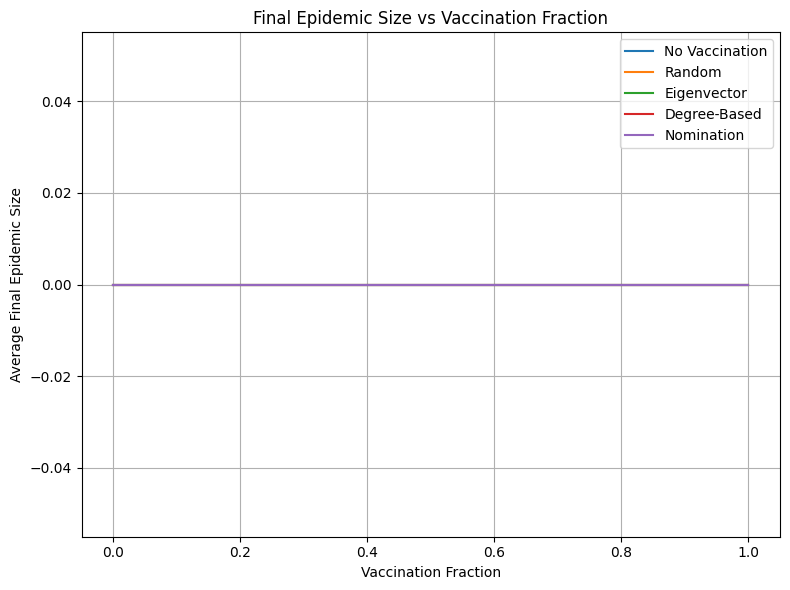

In [52]:
# Q1(vii) – Safe Plot (prevents dimension crash)

n = len(vax_fracs)

plt.figure(figsize=(8, 6))

plt.plot(vax_fracs, results_no_vax[:n], label="No Vaccination")
plt.plot(vax_fracs, results_random[:n], label="Random")
plt.plot(vax_fracs, results_eigen[:n], label="Eigenvector")
plt.plot(vax_fracs, results_degree[:n], label="Degree-Based")
plt.plot(vax_fracs, results_nomination[:n], label="Nomination")

plt.xlabel("Vaccination Fraction")
plt.ylabel("Average Final Epidemic Size")
plt.title("Final Epidemic Size vs Vaccination Fraction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

I am having some trouble with the ordering of the lists, there was a doubling problem. Let me try running some fixes.

In [53]:
results_no_vax = []
results_random = []
results_eigen = []
results_degree = []
results_nomination = []

In [54]:
results_no_vax = []
results_random = []
results_eigen = []
results_degree = []
results_nomination = []

beta = 0.3
gamma = 0.1
rho = 0.02
num_realizations = 50

In [ ]:
for f in vax_fracs:
    
    avg_no_vax = 0
    avg_random = 0
    avg_eigen = 0
    avg_degree = 0
    avg_nomination = 0

    for _ in range(num_realizations):
        
        # --- a) NO VACCINATION ---
        t, S, I, R = EoN.fast_SIR(G, beta, gamma, rho=rho)
        avg_no_vax += R[-1]

        # --- b) RANDOM ---
        H = G.copy()
        H.remove_nodes_from(random_vaccination(G, f))
        if H.number_of_nodes() > 0:
            t, S, I, R = EoN.fast_SIR(H, beta, gamma, rho=rho)
            avg_random += R[-1]

        # --- c) EIGENVECTOR ---
        H = G.copy()
        H.remove_nodes_from(eigenvector_vaccination(G, f))
        if H.number_of_nodes() > 0:
            t, S, I, R = EoN.fast_SIR(H, beta, gamma, rho=rho)
            avg_eigen += R[-1]

        # --- d) DEGREE ---
        H = G.copy()
        H.remove_nodes_from(degree_vaccination(G, f))
        if H.number_of_nodes() > 0:
            t, S, I, R = EoN.fast_SIR(H, beta, gamma, rho=rho)
            avg_degree += R[-1]

        # --- e) NOMINATION ---
        H = G.copy()
        H.remove_nodes_from(nomination_vaccination(G, f))
        if H.number_of_nodes() > 0:
            t, S, I, R = EoN.fast_SIR(H, beta, gamma, rho=rho)
            avg_nomination += R[-1]

    results_no_vax.append(avg_no_vax / num_realizations)
    results_random.append(avg_random / num_realizations)
    results_eigen.append(avg_eigen / num_realizations)
    results_degree.append(avg_degree / num_realizations)
    results_nomination.append(avg_nomination / num_realizations)

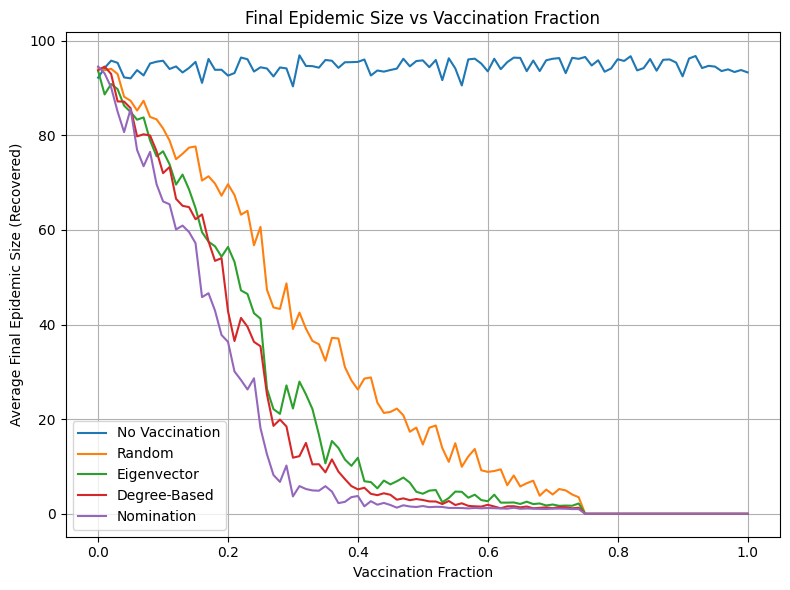

In [56]:
n = len(vax_fracs)

plt.figure(figsize=(8, 6))

plt.plot(vax_fracs, results_no_vax[:n], label="No Vaccination")
plt.plot(vax_fracs, results_random[:n], label="Random")
plt.plot(vax_fracs, results_eigen[:n], label="Eigenvector")
plt.plot(vax_fracs, results_degree[:n], label="Degree-Based")
plt.plot(vax_fracs, results_nomination[:n], label="Nomination")

plt.xlabel("Vaccination Fraction")
plt.ylabel("Average Final Epidemic Size (Recovered)")
plt.title("Final Epidemic Size vs Vaccination Fraction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


It finally works, I'm nervous to move around things in case it breaks again!